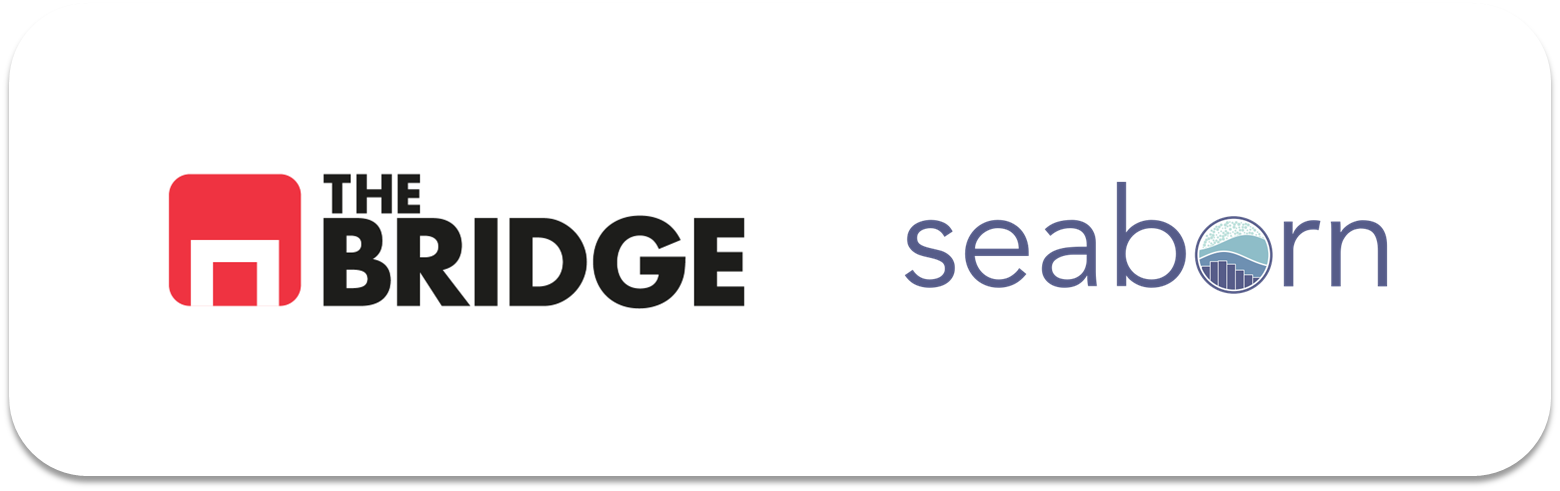

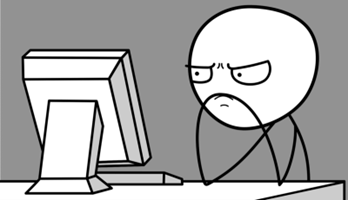

Para ejercitarte y afianzar lo aprendido sobre visualización de datos de una sola variable, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

### Ejercicio 1

Carga los siguientes datasets que necesitarás para poder hacer el resto de ejercicios:
1. Titanic, "./data/titanic.csv"
2. Bitcoin, "./data/BTC.csv"
3. Viajes, "./data/dataset_viajes_jun23"

En el dataset de Bitcoin, convierte la columna "date" a datetime y luego hazla el índice del dataframe.

In [4]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_bitcoin = pd.read_csv("./data/BTC.csv")
df_viajes = pd.read_csv("C:\\Users\\blanc.TORRE-BLANCA\\OneDrive\\Escriptori\\bootcamp-data\\DS-Online-blanca\\03_Data_Analysis\\Sprint_08\\Unidad_02_Visualizacion_Avanzada_Seaborn\\02_Ejercicios_Workout\\data\\dataset_viajes_jun23.csv")

In [5]:
df_bitcoin["fechas"]=pd.to_datetime(df_bitcoin['date'])
df_bitcoin.set_index("fechas", inplace=True)
df_bitcoin.drop("date",axis= 1, inplace=True)
df_bitcoin.head()

,unix,symbol,open,high,low,close,Volume BTC,Volume USD
fechas,,,,,,,,
2022-03-01,1646092800,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
2022-02-28,1646006400,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2022-02-27,1645920000,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
2022-02-26,1645833600,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
2022-02-25,1645747200,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


### Ejercicio 2

Crea una función a la que puedas pasar como argumentos un dataframe y una lista de columnas categóricas y dibuje una matriz de gráficas de 2 columnas y tantas filas como necesite para pintar el diagrama de barras de las frecuencias absolutas de las columnas pasadas como argumento. No hace falta que compruebes que las columnas son categóricas. Y que ponga como título de cada figura "Frecuencias Absolutas de \<nombre de la columna>\. Utiliza Seaborn para dibujar las gráficas y matplotlib para lo que necesites (pero no para dibujar las gráficas)

In [12]:
import math

def matriz_frecuencias(df, columnas):
    # Número de columnas categóricas a graficar
    n = len(columnas)
    filas = math.ceil(n / 2)  # número de filas necesarias

    # Crear figura y ejes
    fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
    axs = axs.flatten()  # convertir a lista plana para iterar fácilmente

    # Dibujar cada gráfico
    for i, col in enumerate(columnas):
        # Calcular frecuencias absolutas
        conteos = df[col].value_counts()

        # Gráfico de barras con Seaborn
        sns.barplot(
            x=conteos.index,
            y=conteos.values,
            hue=conteos.index,      # asigna cada categoría como hue
            palette="viridis",
            legend=False,
            ax=axs[i]
        )


        # Título y etiquetas
        axs[i].set_title(f"Frecuencias Absolutas de {col}", fontsize=14)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel("Frecuencia absoluta")

        # Rotar etiquetas si son largas
        axs[i].tick_params(axis="x", rotation=45)

    # Eliminar ejes sobrantes si hay menos gráficos que subplots
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()




### Ejercicio 3

Utiliza la función anterior para pintar las gráficas de frecuencias de las variables categóricas `alive,embark_town,who` del dataset de titanic


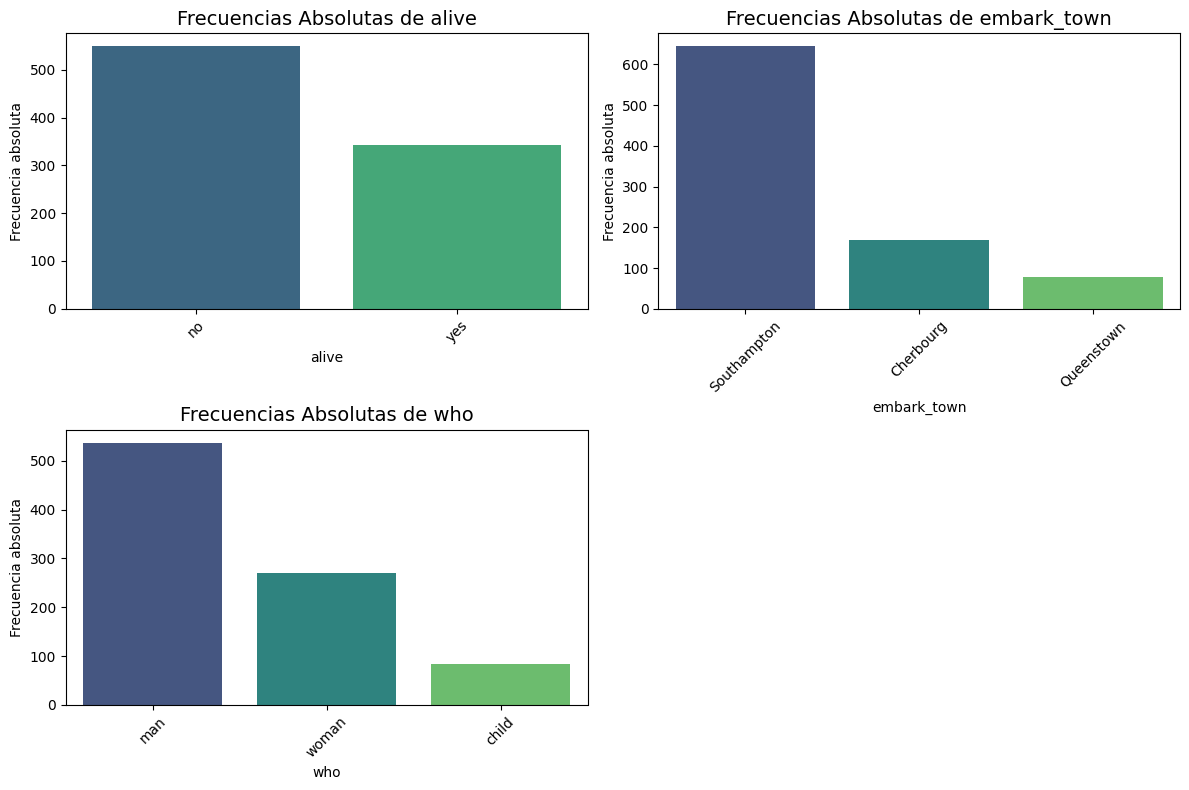

In [13]:
matriz_frecuencias(df_titanic, ["alive", "embark_town", "who"]);


### Ejercicio 4

Crea una función similar a la del ejercicio 4, pero que esta vez pinte el histograma de una lista de columnas numéricas, añade un argumento para poder indicar el número de bins. Añade también un argumento que permita incluir la función de densidad o no en la figura. De nuevo usa Seaborn para crear las figuras. También debe cumplirse el que pinte cada grafica en una matriz de 2 columnas como mucho y todas las filas que necesites.

In [14]:
def matriz_histogramas(df, columnas, bins=30, incluir_densidad=False):
    """
    Dibuja una matriz de histogramas para las columnas numéricas indicadas.
    
    Parámetros:
    - df: DataFrame con los datos
    - columnas: lista de nombres de columnas numéricas
    - bins: número de bins para el histograma
    - incluir_densidad: bool, si True añade la curva de densidad
    """
    n = len(columnas)
    filas = math.ceil(n / 2)  # número de filas necesarias
    fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
    axs = axs.flatten()

    for i, col in enumerate(columnas):
        # Histograma con Seaborn
        sns.histplot(
            data=df,
            x=col,
            bins=bins,
            kde=incluir_densidad,
            ax=axs[i],
            color="steelblue"
        )

        # Título y etiquetas
        axs[i].set_title(f"Histograma de {col}", fontsize=14)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel("Frecuencia")

    # Eliminar ejes sobrantes si hay menos gráficos que subplots
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()



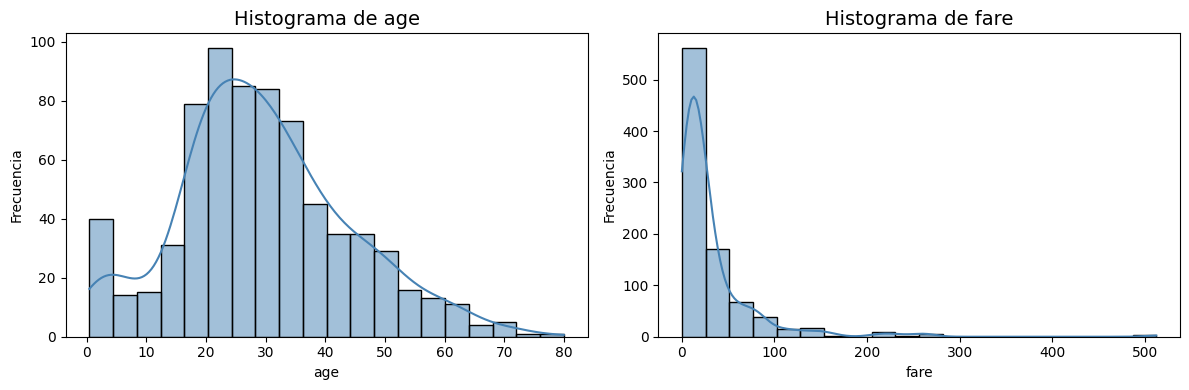

In [17]:
# Pintar histogramas de columnas numéricas
matriz_histogramas(df_titanic, ["age", "fare"], bins=20, incluir_densidad=True);


### Ejercicio 5

Aplica la función del ejercicio anterior para pintar los histogramas de las columnas "ingresos", "consumo_kg" y "duracion" del dataset de viajes pero aplicando la siguiente lista de bins [10,30,60]. Aunque no seamos muy pro-histrogramas, ¿con cuál las posibles gráficas te quedarías para visualizar los valores de cada variable?

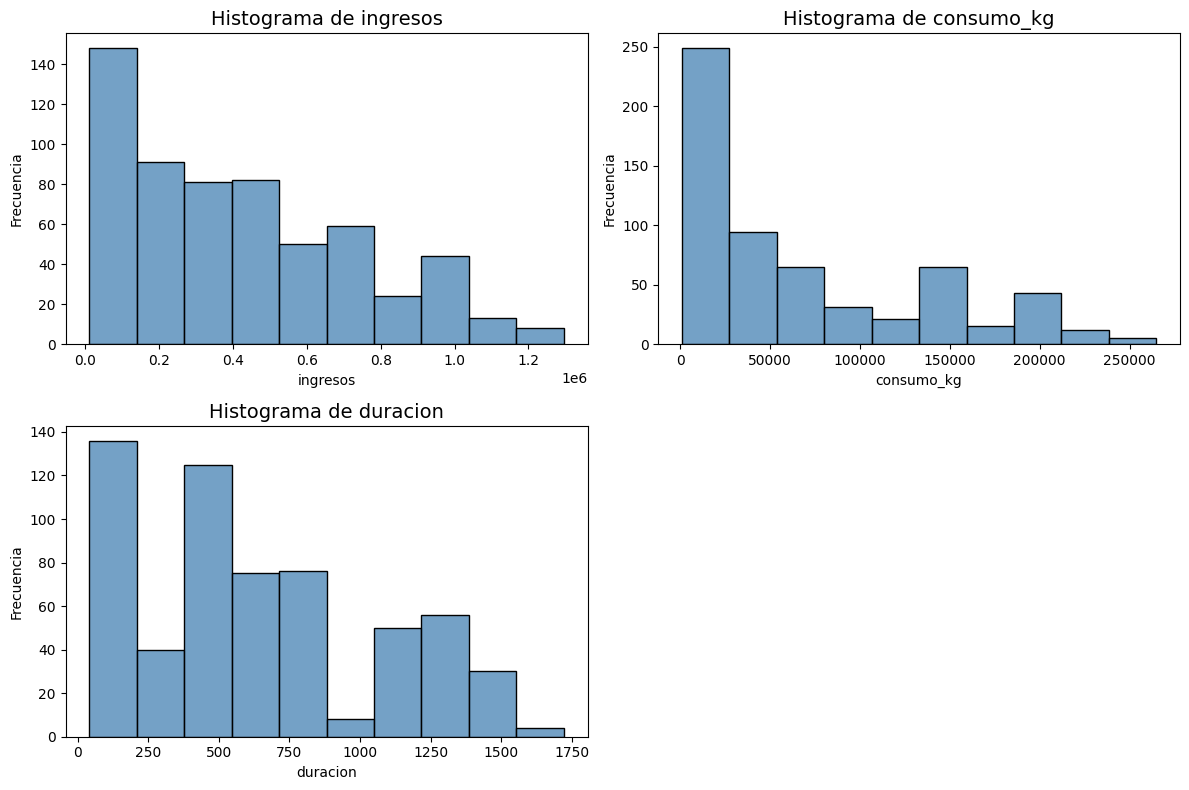

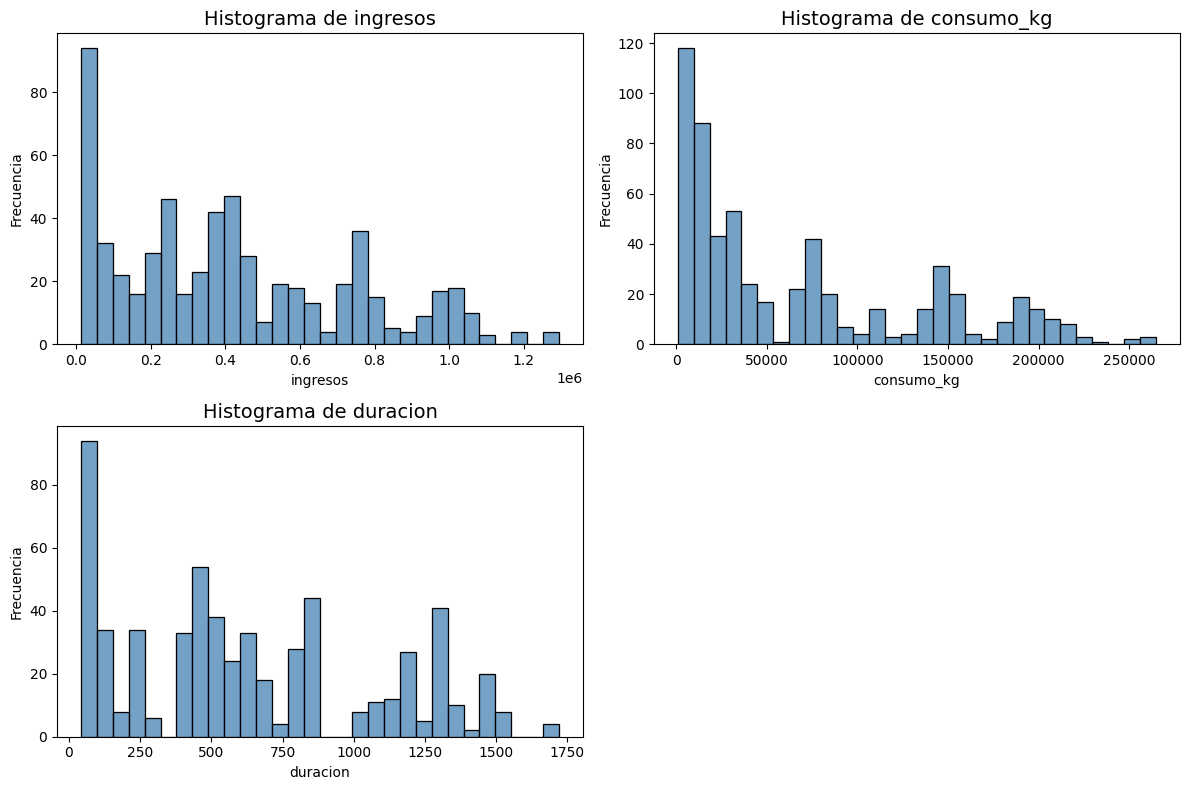

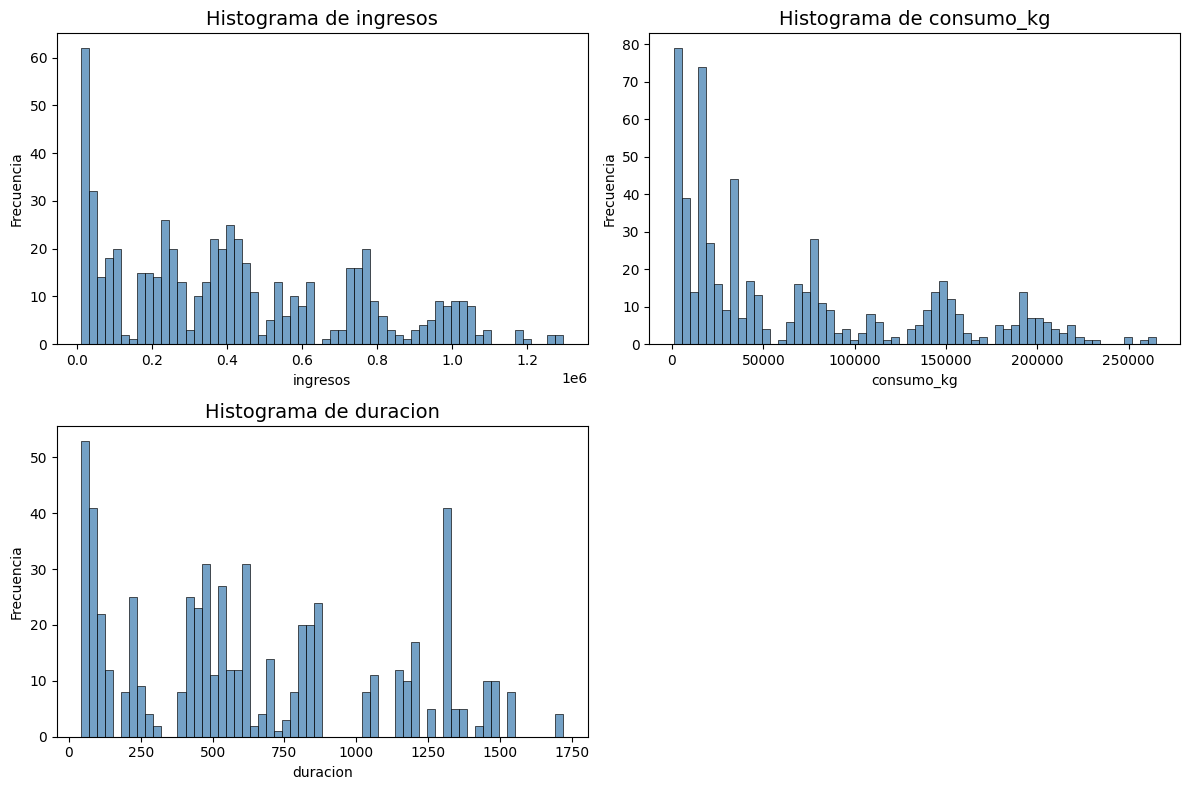

In [18]:
# Suponiendo que ya tienes cargado tu DataFrame "df_viajes"
# con las columnas: ingresos, consumo_kg, duracion

# Bins = 10
matriz_histogramas(df_viajes, ["ingresos", "consumo_kg", "duracion"], bins=10, incluir_densidad=False)

# Bins = 30
matriz_histogramas(df_viajes, ["ingresos", "consumo_kg", "duracion"], bins=30, incluir_densidad=False)

# Bins = 60
matriz_histogramas(df_viajes, ["ingresos", "consumo_kg", "duracion"], bins=60, incluir_densidad=False)

### Ejercicio 6

Construye una función a la que puedas pasar un dataframe y una serie de columnas numéricas (que suponemos son series temporales o secuencias) y que pinte cada columna en una sola gráfica (de nuevo en una matriz de 2 columnas como mucho).

In [29]:
def matriz_series(df, columnas, columna_tiempo=None):
    n = len(columnas)
    filas = math.ceil(n / 2)
    fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
    axs = axs.flatten()

    palette = sns.color_palette("tab10", n)

    for i, col in enumerate(columnas):
        if columna_tiempo is None:
            sns.lineplot(x=df.index, y=df[col], ax=axs[i], color=palette[i])
            axs[i].set_xlabel("Índice")
        else:
            sns.lineplot(data=df, x=columna_tiempo, y=col, ax=axs[i], color=palette[i])
            axs[i].set_xlabel(columna_tiempo)

        axs[i].set_title(f"Serie temporal de {col}", fontsize=14)
        axs[i].set_ylabel(col)

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()


### Ejercicio 7

Visualiza las columnas `open`,`close`,`high`,`low` del dataset de Bitcoin. 

In [30]:
df_bitcoin.head()

,unix,symbol,open,high,low,close,Volume BTC,Volume USD
fechas,,,,,,,,
2022-03-01,1646092800,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
2022-02-28,1646006400,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2022-02-27,1645920000,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
2022-02-26,1645833600,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
2022-02-25,1645747200,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


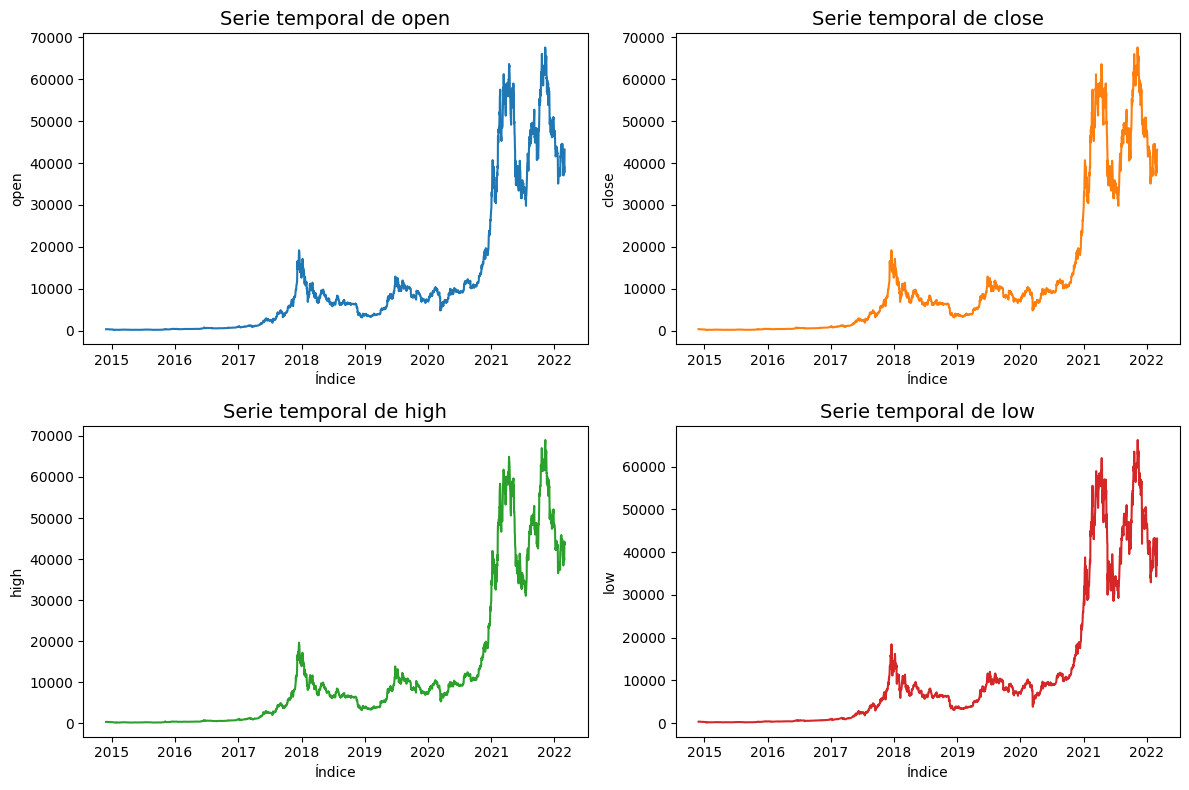

In [31]:
matriz_series(df_bitcoin, ["open", "close", "high", "low"])



### Ejercicio 8

Añade tres argumentos a la funcion del ejercicio 6. El primero debe permitir pintar una sola gráfica con todas las líneas de evolución juntas y añadir una leyenda. El segundo debe permitir colocar una fecha de inicio y el tercero una fecha de fin. Si no se dan valores a estos argumentos la figura debe contemplarlos todos, si se dan la figura sólo debe mostrar los valores comprendidos entre esas fechas. Supon que la fecha es el índice del DataFrame. De nuevo las gráficas deben estar pintadas con Seaborn.

In [32]:

def matriz_series(df, columnas, juntar=False, fecha_inicio=None, fecha_fin=None):
    """
    Dibuja gráficas de evolución para columnas numéricas (series temporales o secuencias).
    
    Parámetros:
    - df: DataFrame con índice temporal
    - columnas: lista de columnas numéricas
    - juntar: si True, dibuja todas las series en una sola gráfica con leyenda
    - fecha_inicio: fecha mínima (como string o datetime)
    - fecha_fin: fecha máxima (como string o datetime)
    """
    # Filtrar por fechas si se especifican
    if fecha_inicio is not None:
        df = df[df.index >= fecha_inicio]
    if fecha_fin is not None:
        df = df[df.index <= fecha_fin]

    # Dibujar todas juntas
    if juntar:
        plt.figure(figsize=(12, 6))
        palette = sns.color_palette("tab10", len(columnas))
        for i, col in enumerate(columnas):
            sns.lineplot(x=df.index, y=df[col], label=col, color=palette[i])
        plt.title("Evolución conjunta de las variables")
        plt.xlabel("Fecha")
        plt.ylabel("Valor")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        # Dibujar por separado en matriz de 2 columnas
        n = len(columnas)
        filas = math.ceil(n / 2)
        fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
        axs = axs.flatten()
        palette = sns.color_palette("tab10", n)

        for i, col in enumerate(columnas):
            sns.lineplot(x=df.index, y=df[col], ax=axs[i], color=palette[i])
            axs[i].set_title(f"Serie temporal de {col}", fontsize=14)
            axs[i].set_xlabel("Fecha")
            axs[i].set_ylabel(col)

        for j in range(i+1, len(axs)):
            fig.delaxes(axs[j])

        plt.tight_layout()
        plt.show()


### Ejercicio 9

Muestra el periodo más interesante y sólo ese de las variables `open`,`close` (de forma conjunta) del dataset de Bitcoin. Usa la función creada en el ejercicio anterior.

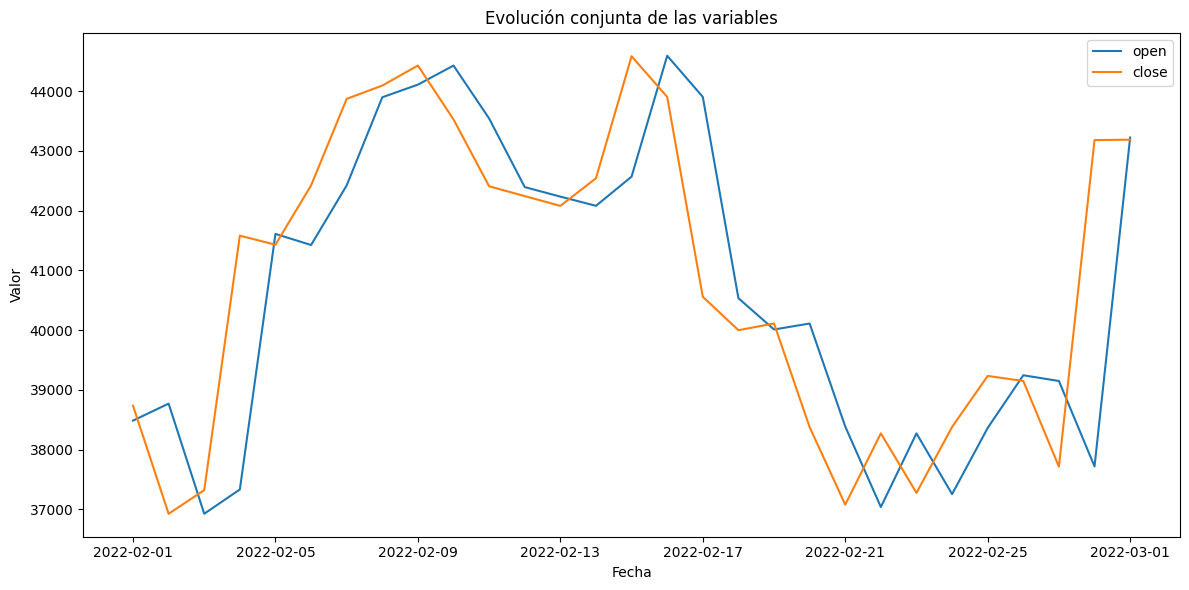

In [33]:
# Suponiendo que df_bitcoin tiene el índice como fechas
matriz_series(
    df_bitcoin,
    ["open", "close"],
    juntar=True,                  # todas las líneas en una sola gráfica
    fecha_inicio="2022-02-01",    # inicio del periodo
    fecha_fin="2022-03-15"        # fin del periodo
)